# Cas reel du benchmark : la difference de metriques vient de Meek (R3)

Cas sem_gaussian, 10 variables, graphe 3, n=200 — un run ou les metriques CMIIC
different entre agrum2 (avril) et agrum3 (juillet).

Chaine verifiee :
1. memes donnees (regenerees a l'identique) ;
2. `learnPDAG` identique entre otagrum 0.13 et 0.15 — et c'est un squelette pur (0 v-structure) ;
3. la completion Meek de ce meme P donne, sous chaque version, **exactement** la structure
   sauvegardee dans les resultats correspondants (avril / juillet).

Toute la difference vient donc de la completion — dont le seul changement substantiel est la R3 :
https://gitlab.com/agrumery/aGrUM/-/commit/13b8f2c8a87c6d87262f91bbd042b8d6c81e5188

Run All avec le kernel agrum3 (cbnsl), puis avec le kernel agrum2 (venv) ; la derniere cellule compare.

In [9]:
import json
import sys
from pathlib import Path
sys.path.insert(0, "../..")

import openturns as ot
import otagrum
import pyagrum as gum
import pyagrum.lib.notebook as gnb

from data.generators import generate_from_sem

VERSION = f"agrum{gum.__version__.split('.')[0]}"
RESULTS = Path("/tmp/r3_real_case")
RESULTS.mkdir(parents=True, exist_ok=True)

SCALING = Path("../scaling")
GOLDEN_FILE = SCALING / "agrum2/results/2026-04-02_10h34_sem_gaussian/graphs/golden__v10_a15_g3.json"
AVRIL_FILE = SCALING / "agrum2/results/2026-04-02_10h34_sem_gaussian/graphs/CMIIC__v10_a15_g3_s200.json"
JUILLET_FILE = SCALING / "agrum3/cpc_bug_run/2026-07-22_11h39_sem_gaussian/graphs/CMIIC__v10_a15_g3_s200.json"

print(VERSION, "| pyagrum", gum.__version__, "| otagrum", otagrum.__version__)

agrum3 | pyagrum 3.0.0 | otagrum 0.15


DAG regenere == fichier golden : OK


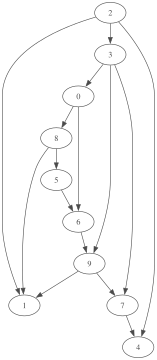

In [10]:
# Le golden est lu depuis le fichier de resultats d'avril.
golden = json.loads(GOLDEN_FILE.read_text())

# Pour regenerer les donnees a l'identique, le DAG doit etre reconstruit par la
# recette exacte du runner (l'ordre d'insertion des arcs influe sur le tirage
# des poids dans generate_from_sem) : BNGenerator seede, puis DAG nu.
gum.initRandom(42 + 3)  # seed du runner + graph_idx
bn = gum.BNGenerator().generate(n_nodes=10, n_arcs=15)
dag = gum.DAG()
dag.addNodes(10)
for arc in bn.dag().arcs():
    dag.addArc(*arc)

assert sorted([t, h] for t, h in dag.arcs()) == sorted(map(list, golden["arcs"])), \
    "le DAG regenere ne correspond pas au fichier golden"
print("DAG regenere == fichier golden : OK")
gnb.showDot(dag.toDot())

In [11]:
dataset, _ = generate_from_sem(dag, 200, seed=42, noise_type="gaussian")
sample = ot.Sample(dataset.data)
sample.setDescription([f"X{i}" for i in range(10)])

learner = otagrum.ContinuousMIIC(sample)
learner.setAlpha(0.05)
p = learner.learnPDAG()
print(f"learnPDAG ({VERSION}) : {len(p.arcs())} arcs, {len(p.edges())} edges")

learned_dag = learner.learnDAG().getDAG()
bn2 = gum.BayesNet()
for i in range(10):
    bn2.add(gum.LabelizedVariable(f"X{i}", "", 2))
for t, h in learned_dag.arcs():
    bn2.addArc(t, h)
eg = gum.EssentialGraph(bn2)
cpdag = eg.pdag()

(RESULTS / f"{VERSION}.json").write_text(json.dumps({
    "pdag_arcs": sorted([t, h] for t, h in p.arcs()),
    "pdag_edges": sorted([min(e), max(e)] for e in p.edges()),
    "cpdag_arcs": sorted([t, h] for t, h in cpdag.arcs()),
    "cpdag_edges": sorted([min(e), max(e)] for e in cpdag.edges()),
}))
print("CPDAG appris (EssentialGraph(learnDAG)) sauvegarde")

learnPDAG (agrum3) : 0 arcs, 12 edges
CPDAG appris (EssentialGraph(learnDAG)) sauvegarde


In [12]:
versions = sorted(f.stem for f in RESULTS.glob("agrum*.json"))
assert len(versions) == 2, "lancer d'abord ce notebook dans les deux kernels (cbnsl et venv)"

recomputed = {v: json.loads((RESULTS / f"{v}.json").read_text()) for v in versions}

print("learnPDAG identique entre les deux versions d'otagrum :",
      recomputed["agrum2"]["pdag_arcs"] == recomputed["agrum3"]["pdag_arcs"]
      and recomputed["agrum2"]["pdag_edges"] == recomputed["agrum3"]["pdag_edges"])

def norm_file(path):
    d = json.loads(path.read_text())
    return {"arcs": sorted(map(list, d["arcs"])), "edges": sorted(map(list, d["edges"]))}

fichiers = {"agrum2": norm_file(AVRIL_FILE), "agrum3": norm_file(JUILLET_FILE)}
for v in versions:
    match = (fichiers[v]["arcs"] == recomputed[v]["cpdag_arcs"]
             and fichiers[v]["edges"] == recomputed[v]["cpdag_edges"])
    print(f"completion {v} == structure sauvegardee ({'avril' if v == 'agrum2' else 'juillet'}) : {match}")

def pdag_from(sig):
    p = gum.PDAG()
    for i in range(10):
        p.addNodeWithId(i)
    for t, h in sig["arcs"]:
        p.addArc(t, h)
    for u, v in sig["edges"]:
        p.addEdge(u, v)
    return p

# golden CPDAG = essential graph du golden DAG
bn_g = gum.BayesNet()
for i in range(10):
    bn_g.add(gum.LabelizedVariable(f"X{i}", "", 2))
for t, h in golden["arcs"]:
    bn_g.addArc(t, h)
eg_g = gum.EssentialGraph(bn_g)
golden_cpdag = eg_g.pdag()

gnb.sideBySide(
    gnb.getDot(dag.toDot()),
    gnb.getDot(golden_cpdag.toDot()),
    captions=["golden DAG (genere les donnees)", "golden CPDAG"])

gnb.sideBySide(
    gnb.getDot(pdag_from({"arcs": recomputed["agrum2"]["pdag_arcs"],
                          "edges": recomputed["agrum2"]["pdag_edges"]}).toDot()),
    gnb.getDot(pdag_from(fichiers["agrum2"]).toDot()),
    gnb.getDot(pdag_from({"arcs": recomputed["agrum3"]["pdag_arcs"],
                          "edges": recomputed["agrum3"]["pdag_edges"]}).toDot()),
    gnb.getDot(pdag_from(fichiers["agrum3"]).toDot()),
    captions=["CPDAG appris par agrum2\n(learnPDAG, otagrum 0.13)",
              "EssentialGraph(learnDAG) agrum2\n(= fichier avril)",
              "CPDAG appris par agrum3\n(learnPDAG, otagrum 0.15)",
              "EssentialGraph(learnDAG) agrum3\n(= fichier juillet)"])

learnPDAG identique entre les deux versions d'otagrum : True
completion agrum2 == structure sauvegardee (avril) : True
completion agrum3 == structure sauvegardee (juillet) : True
